<a href="https://colab.research.google.com/github/SaiSuhasBilla/Music_VAE/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!curl -L -o /content/genres_original.zip "https://www.kaggle.com/api/v1/datasets/download/andradaolteanu/gtzan-dataset-music-genre-classification"

import zipfile
with zipfile.ZipFile('/content/genres_original.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

if os.path.exists('/content/Data/genres_original'):
    !mv /content/Data/genres_original /content/genres_original
print(" Dataset pulled ")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1241M  100 1241M    0     0  37.6M      0  0:00:32  0:00:32 --:--:-- 35.5M
 Dataset pulled 


In [23]:
import os
import librosa
import numpy as np
import tensorflow as tf

BASE_PATH = '/content/genres_original'
AUDIO_DURATION = 30
TARGET_SHAPE = 90001
BATCH_SIZE = 10
AUTOTUNE = tf.data.AUTOTUNE

def DatasetLoader(class_name):
    available_folders = os.listdir(BASE_PATH)
    matched_folder = [f for f in available_folders if f.lower() == class_name.lower()]

    if not matched_folder:
        raise FileNotFoundError(f"❌ Error: Cannot find folder '{class_name}'. Available: {available_folders}")

    class_dir = os.path.join(BASE_PATH, matched_folder[0])
    music_list = np.array(sorted(os.listdir(class_dir)))
    music_list = [f for f in music_list if f.endswith('.wav')]

    train_idx = [0, 52, 19, 39, 71, 12, 75, 85, 3, 45, 24, 46, 88]
    test_idx = [4, 43, 56, 55, 45, 31, 11, 13, 70, 37, 21, 78]

    train_idx = [i for i in train_idx if i < len(music_list)]
    test_idx = [i for i in test_idx if i < len(music_list)]

    train_music = list(np.array(music_list)[train_idx])
    test_music = list(np.array(music_list)[test_idx])

    TrackSet_1 = [os.path.join(class_dir, x) for x in train_music]
    TrackSet_2 = [os.path.join(class_dir, x) for x in test_music]
    return TrackSet_1, TrackSet_2

def load_native(file_tensor):
    if hasattr(file_tensor, 'numpy'):
        file_path = file_tensor.numpy().decode('utf-8')
    else:
        file_path = file_tensor
    data_, _ = librosa.load(file_path, sr=3000, offset=0.0, duration=AUDIO_DURATION)
    if len(data_) < TARGET_SHAPE:
        data = np.pad(data_, (0, TARGET_SHAPE - len(data_)), 'constant')
    else:
        data = data_[:TARGET_SHAPE]
    return data.reshape(1, TARGET_SHAPE).astype(np.float32)

def map_data_fn(filename):
    [data] = tf.py_function(load_native, [filename], [tf.float32])
    data.set_shape((1, TARGET_SHAPE))
    return data

TrackSet_1, TrackSet_2 = DatasetLoader('jazz')

train_dataset = (
    tf.data.Dataset.from_tensor_slices(TrackSet_1)
    .map(map_data_fn, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(15)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(TrackSet_2)
    .map(map_data_fn, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
print("✅ Datasets successfully loaded! 'test_dataset' is now defined.")

✅ Datasets successfully loaded! 'test_dataset' is now defined.


In [26]:
import time
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import clear_output

epochs = 20

@tf.function
def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2. * np.pi)
    return tf.reduce_sum(-.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi), axis=raxis)

@tf.function
def compute_loss(model, x):
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z)

    x_logit = tf.clip_by_value(x_logit, -20.0, 20.0)

    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    logpx_z = -tf.reduce_sum(cross_ent, axis=[1,2])
    logpz = log_normal_pdf(z, 0., 0.)
    logqz_x = log_normal_pdf(z, mean, logvar)
    return -tf.reduce_mean(logpx_z + logpz - logqz_x)

def train_step(model, x, target_optimizer):
    with tf.GradientTape() as tape:
        mean, logvar = model.encode(x)
        z = model.reparameterize(mean, logvar)
        x_logit = model.decode(z)

        x_logit = tf.clip_by_value(x_logit, -20.0, 20.0)

        cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
        logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2])
        logpz = log_normal_pdf(z, 0., 0.)
        logqz_x = log_normal_pdf(z, mean, logvar)
        loss_KL = -tf.reduce_mean(logpx_z + logpz - logqz_x)
        reconstruction_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(x, x_logit))
        total_loss = reconstruction_loss + loss_KL

    gradients = tape.gradient(total_loss, model.trainable_variables)

    gradients = [tf.where(tf.math.is_nan(g), tf.zeros_like(g), g) for g in gradients]
    gradients = [tf.where(tf.math.is_inf(g), tf.zeros_like(g), g) for g in gradients]

    clipped_gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
    target_optimizer.apply_gradients(zip(clipped_gradients, model.trainable_variables))

def generate_and_save_images(model, epoch, test_sample, save_prefix):
    mean, logvar = model.encode(test_sample)
    z = model.reparameterize(mean, logvar)
    predictions = model.sample(z)

    if not np.isfinite(predictions.numpy()).all():
        print("⚠️ Warning: Output contained non-finite values. Graph rendering skipped for safety.")
        return

    fig = plt.figure(figsize=(14, 6))
    for i in range(min(predictions.shape[0], 4)):
        plt.subplot(2, 2, i + 1)
        wave = np.asarray(predictions[i])
        librosa.display.waveshow(wave[0], sr=3000)
        plt.title(f"Epoch {epoch} - Track {i+1}")
    plt.tight_layout()
    plt.savefig('{}_{:04d}.png'.format(save_prefix, epoch))
    plt.show()

def train_fast(train_dataset, test_dataset, model, target_optimizer, save_prefix, test_sample):
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        for train_x in train_dataset:
            train_step(model, train_x, target_optimizer)
        end_time = time.time()

        loss = tf.keras.metrics.Mean()
        for test_x in test_dataset:
            loss(compute_loss(model, test_x))

        clear_output(wait=True)
        print(f'Genre Suite: {save_prefix} | Epoch: {epoch} | ELBO: {-loss.result():.2f} | Time: {end_time - start_time:.2f}s')
        generate_and_save_images(model, epoch, test_sample, save_prefix)

def inference_with_normalization(test_dataset, model):
    save_music = []
    for test in test_dataset:
        mean, logvar = model.encode(test)
        z = model.reparameterize(mean, logvar)
        predictions = model.sample(z)
        for pred in predictions:
            wave = np.asarray(pred)[0]
            max_val = np.max(np.abs(wave))
            if max_val > 0:
                wave = wave / max_val
            save_music.append(wave)
    return save_music

Genre Suite: jazz | Epoch: 20 | ELBO: 2317.09 | Time: 2.75s


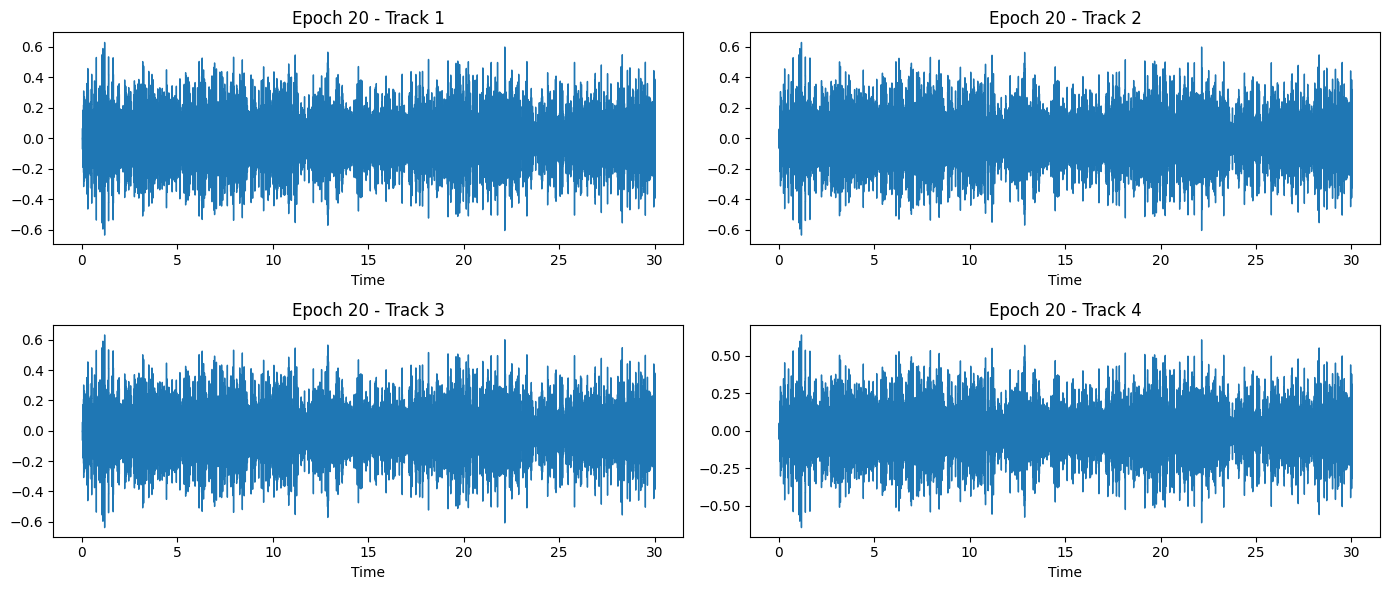

In [28]:
tf.keras.backend.clear_session()

jazz_optimizer = tf.keras.optimizers.Adam(0.0003, beta_1=0.9, beta_2=0.999, epsilon=1e-08, clipnorm=1.0)
model_jazz = CVAE(latent_dim)

for test_batch in test_dataset.take(1):
    test_sample_jazz = test_batch

train_fast(train_dataset, test_dataset, model_jazz, jazz_optimizer, 'jazz', test_sample_jazz)

In [29]:
saved_musics_jazz = inference(test_dataset, model_jazz)

print("🎵 Track 1 Generated Jazz Audio:")
display(Audio(saved_musics_jazz[0][0], rate=3000))

print("🎵 Track 2 Generated Jazz Audio:")
display(Audio(saved_musics_jazz[9][0], rate=3000))

🎵 Track 1 Generated Jazz Audio:


🎵 Track 2 Generated Jazz Audio:


Genre Suite: classical | Epoch: 20 | ELBO: 1165.96 | Time: 2.45s


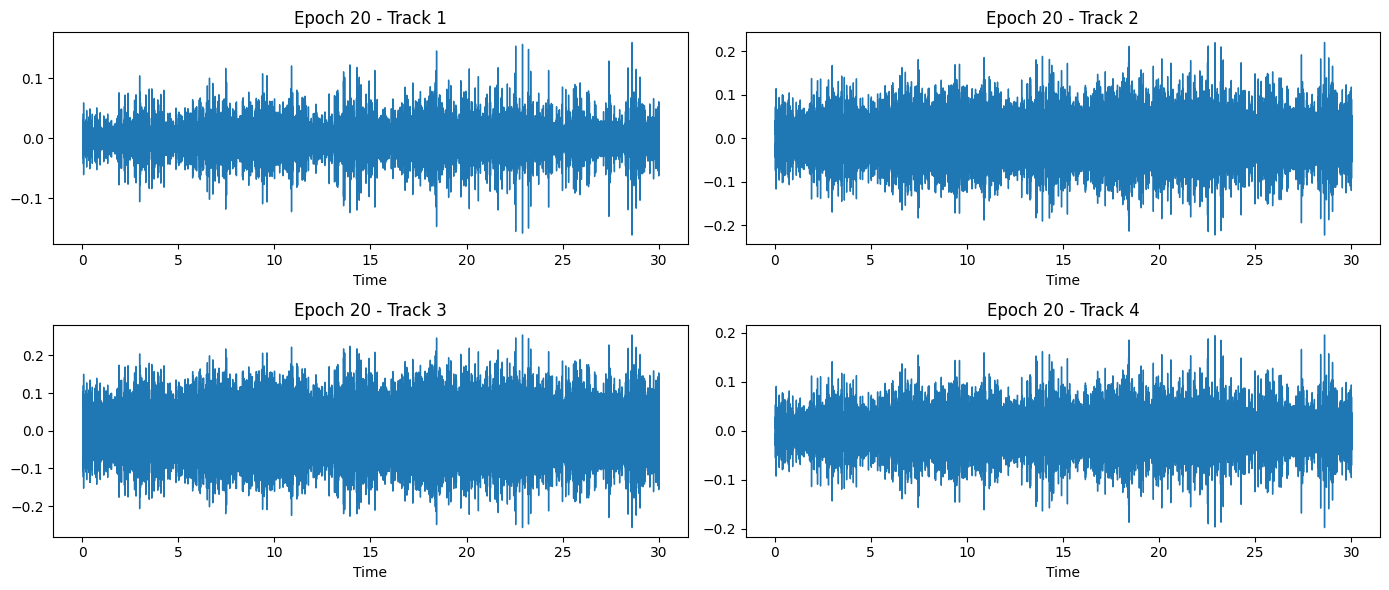

In [30]:
import tensorflow as tf

classical_optimizer = tf.keras.optimizers.Adam(0.0003, beta_1=0.9, beta_2=0.999, epsilon=1e-08, clipnorm=1.0)
model_classic = CVAE(latent_dim)

TrackSet_3, TrackSet_4 = DatasetLoader('classical')

train_dataset_classic = (
    tf.data.Dataset.from_tensor_slices(TrackSet_3)
    .map(map_data_fn, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(15)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset_classic = (
    tf.data.Dataset.from_tensor_slices(TrackSet_4)
    .map(map_data_fn, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

for test_batch in test_dataset_classic.take(1):
    test_sample_classic = test_batch

train_fast(train_dataset_classic, test_dataset_classic, model_classic, classical_optimizer, 'classical', test_sample_classic)

In [31]:
from IPython.display import Audio, display

saved_musics_classic = inference_with_normalization(test_dataset_classic, model_classic)

print("🎵 Track 1 Generated Classical Audio:")
display(Audio(saved_musics_classic[1], rate=3000))

print("🎵 Track 2 Generated Classical Audio:")
display(Audio(saved_musics_classic[9], rate=3000))

🎵 Track 1 Generated Classical Audio:


🎵 Track 2 Generated Classical Audio:
